# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}


In [8]:
params =  {'m': -2, 'c': 1e8, 'l': 7e4}


In [9]:
data =  Elias27

In [10]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 300

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

dir_fits =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [11]:
u.dtype

dtype('float64')

In [12]:
import os

os.environ["OMP_NUM_THREADS"] = "16"

In [13]:
import os
print(os.environ["OMP_NUM_THREADS"])

16


# Disk

In [14]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [15]:
print(frank2d.gridded_data['vis'].dtype, type(frank2d.gridded_data['vis']))

complex128 <class 'numpy.ndarray'>


In [16]:
best_params = params

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.10  min |  6.27 seconds
--> time = 0.11  min |  6.57 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 0.568490775759831
Final tolerance :  0.568490775759831
.... iteration:  0
                        -> actual tol:  56849077.57598309 vs  0.568490775759831
.... iteration:  1
                        -> actual tol:  12011595.928403592 vs  0.568490775759831
.... iteration:  2
                        -> actual tol:  42482391.45191967 vs  0.568490775759831
.... iteration:  3
                        -> actual tol:  46375051.60767541 vs  0.568490775759831
.... iteration:  4
                        -> actual tol:  9131660.443073168 vs  0.568490775759831
.... iteration:  5
                        -> actual tol:  4161671.719890695 vs  0.568490775759831
.... iteration:  6
                        -> actual tol:  3591272.2373207575 vs  0.568490775759831
.... iteration:  7
           

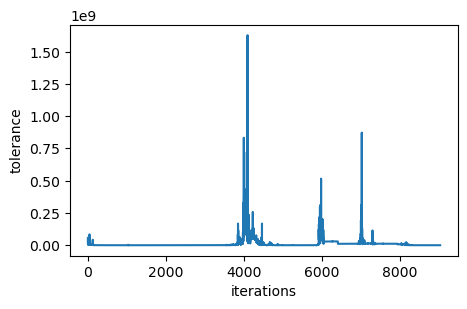

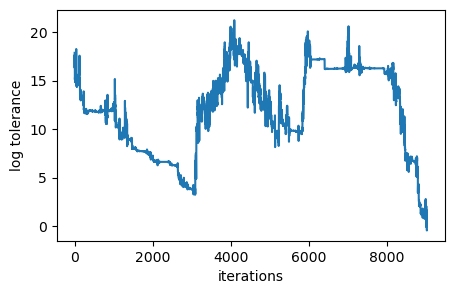

--> time = 20.26  min |  1215.73 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.14  min |  8.57 seconds


In [17]:
frank2d.fit(kernel_params = best_params, rtol = 1e-8)

### Best

In [18]:
ME = MAPEstimator(frank2d._Rmax,  frank2d._Geometry)

In [19]:
frank2d.set_MAP_estimator(ME)

Setting MAP estimator...


In [20]:
frank2d.search_MAP()

Using existing visibility data...
Fitting the visibilities with Frank2D with 2DFT...
  + Time to set up the matrices: 51.61 seconds
Setting the initial guess...
Optimizing the posterior...


In [21]:
frank2d.MAP

{'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}

### Plot

In [18]:
Plot_= Plot(frank2d, geom)

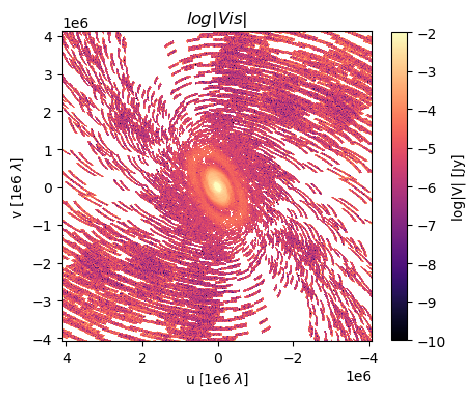

In [19]:
Plot_.visibility(fig_size = 5, kind = 'input')

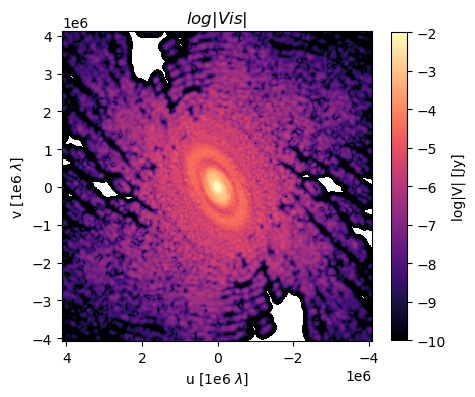

In [20]:
Plot_.visibility(fig_size = 5)

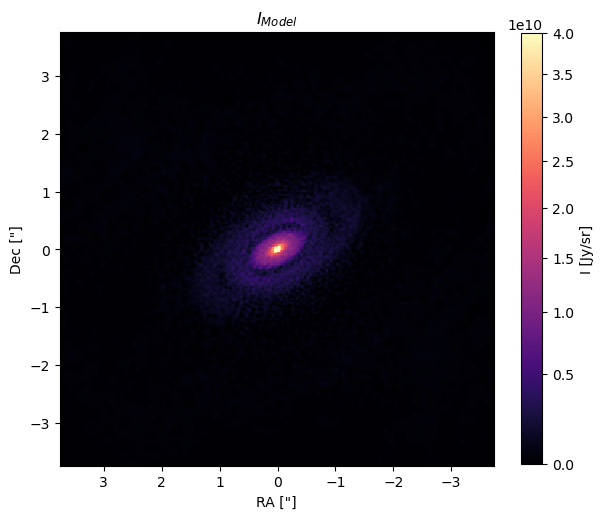

In [21]:
Plot_.intensity(fig_size = 7, vmax = 4e10, gamma = 0.75)

In [21]:
Plot_.visibility_profile(input = uvtable, weighted = True, frank1d = True)

Frank1D profile not set.Using gridded visibilities as input.
Performing 1D Frank fit...

$\alpha$ =  1.05  and $w_{smooth}$ =  0.001

N =  300  and $R_{max}$ =  None


KeyboardInterrupt: 

In [ ]:
Plot_.set_fits_file(fits_file)

In [20]:
Plot_AS209.set_f1d_solution()

TypeError: Plot.set_f1d_solution() missing 1 required positional argument: 'sol'

In [19]:
Plot_AS209.intensity_profile(clean = False)

ValueError: Set your Frank1D profile first. 
Use the 'set_f1d_solution' method.

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
Performing 1D Frank fit...


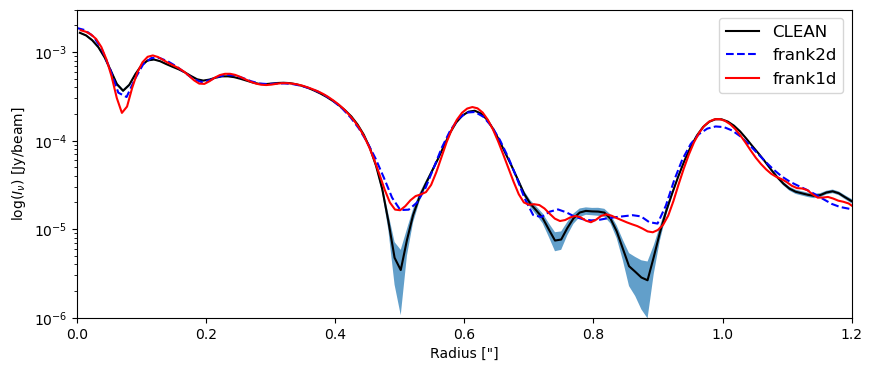

In [ ]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_file)

In [ ]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_1mm_AS209)